<a href="https://colab.research.google.com/github/hemanthcs34/ML2_LAB/blob/main/bagging_and_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


   age  sex  cp  trestbps  chol  fbs  restecg  thalachh  exang  oldpeak  \
0   63    1   3       145   233    1        0       150      0      2.3   
1   37    1   2       130   250    0        1       187      0      3.5   
2   41    0   1       130   204    0        0       172      0      1.4   
3   56    1   1       120   236    0        1       178      0      0.8   
4   57    0   0       120   354    0        1       163      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     2       1  
4      2   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int

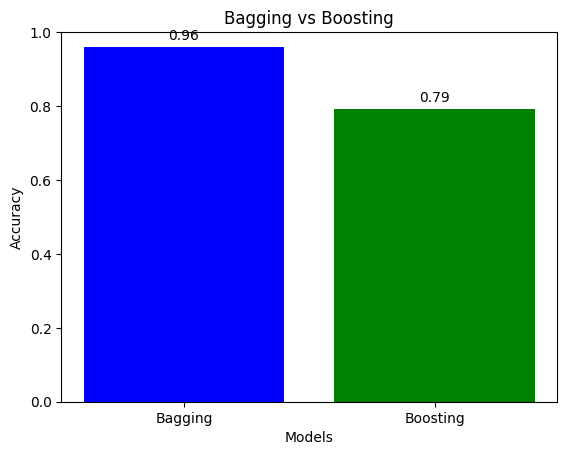

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score


# Read dataset
data = pd.read_csv("heart.csv")

print(data.head())
print(data.info())


# Separate input and output
X = data.drop("target", axis=1)
y = data["target"]


# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# ---------------- BAGGING ----------------

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)

bagging_pred = bagging.predict(X_test)

bagging_accuracy = accuracy_score(
    y_test,
    bagging_pred
)


# ---------------- BOOSTING ----------------

boosting = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

boosting.fit(X_train, y_train)

boosting_pred = boosting.predict(X_test)

boosting_accuracy = accuracy_score(
    y_test,
    boosting_pred
)


# ---------------- RESULTS ----------------

print("\nModel Performance")
print("-------------------------")

print("Bagging Accuracy  :", bagging_accuracy)
print("Boosting Accuracy :", boosting_accuracy)


# ---------------- GRAPH ----------------

models = ["Bagging", "Boosting"]
accuracy = [
    bagging_accuracy,
    boosting_accuracy
]

plt.bar(
    models,
    accuracy,
    color=["blue", "green"]
)

plt.title("Bagging vs Boosting")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Display accuracy on top of bars
for i, value in enumerate(accuracy):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )


plt.show()
